# Testing OT Between Bulk Data
Now that we've validated that OT behaves as expected when adding noise to bulk datasets, we can move to comparing actual bulk datasets (after binning) with one another. To validate if these values make sense, we will compare these values to the scc scores (calculated at 1 Mb).

## Importing Data and Binning

In [2]:
### Importing Cooler Files ###
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import linregress
import ot
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, bin_contact_map, get_cool_name, hic_ot_source_to_targets

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
map_names = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))
    map_names.append(get_cool_name(clr).split("_")[1])

In [3]:
### Binning First Chromosomes ###
chr1s_binned = []
for chr1 in chr1s:
    chr1s_binned.append(bin_contact_map(chr1, 4))

## 1 to All (Old Code)

### Exact OT

In [4]:
### Prepping Data for OT ###
# Selecting data
mpp = chr1s_binned[5]

# Source map
source_mask = np.triu(mpp, k=1) > 0
source_coords = np.column_stack(np.where(source_mask))
source_values = mpp[source_mask]
source_values_max = source_values / source_values.max()
source_values_sum = source_values / source_values.sum()

# Target maps
coords_list = []
values_list = []
values_list_max = []
values_list_sum = []

for target in chr1s_binned:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    coords_list.append(coords)

    # Extracting Raw Values
    values = target[mask]

    # No normalization
    values_none = values * (source_values.sum() / values.sum()) # Normalizing to ensure equivalent weights
    values_list.append(values_none)
    print(values_none.sum())

    # Maximum normalization
    values_max = values / values.max()  # Maximum normalizing
    values_max = values_max * (source_values_max.sum() / values_max.sum()) # Normalizing to ensure equivalent weights
    values_list_max.append(values_max)
    print(values_max.sum())

    # Sum normalization
    values_sum = values / values.sum()   # Sum normalization
    values_list_sum.append(values_sum)
    print(values_sum.sum(), "\n")

507020.0
123.66341463414636
1.0 

507020.0
123.66341463414633
1.0 

507019.99999999994
123.66341463414636
1.0 

507019.99999999994
123.66341463414633
1.0 

507019.99999999994
123.66341463414635
0.9999999999999999 

507020.0
123.66341463414635
1.0 

507020.0
123.66341463414635
0.9999999999999999 

507020.00000000006
123.66341463414636
1.0 

507020.0
123.66341463414633
1.0 

507020.00000000006
123.66341463414635
1.0 



In [5]:
### Exact OT ###
ot_values = []
ot_values_max = []
ot_values_sum = []

for coords, values, values_max, values_sum in zip(coords_list, values_list, values_list_max,
                                                  values_list_sum):
    # Cost matrix
    M = ot.dist(source_coords, coords)
    print("Calculated M")

    # No normalization
    ot_value = ot.solve(M, source_values, values).value
    ot_values.append(ot_value)
    print("Calculated ot_value")

    # Max normalization
    ot_value_max = ot.solve(M, source_values_max, values_max).value
    ot_values_max.append(ot_value_max)
    print("Calculated ot_value_max")

    # Sum normalization
    ot_value_sum = ot.solve(M, source_values_sum, values_sum).value
    ot_values_sum.append(ot_value_sum)
    print("Calculated ot_value_sum")

Calculated M
Calculated ot_value


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/lp/_network_simplex.py:578: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)


Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum
Calculated M
Calculated ot_value
Calculated ot_value_max
Calculated ot_value_sum


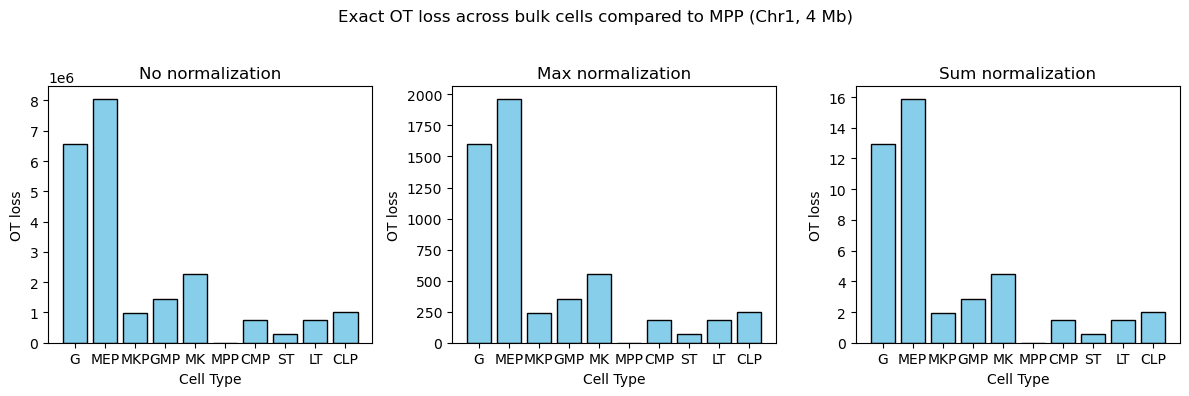

In [6]:
### Plotting ###
ot_results = [ot_values, ot_values_max, ot_values_sum]
labels = ["No normalization", "Max normalization", "Sum normalization"]

fig, axes = plt.subplots(1, 3, figsize=(12,4))

for ax, data, title in zip(axes, ot_results, labels):
    x_pos = range(len(data))
    ax.bar(x_pos, data, color='skyblue', edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel("Cell Type")
    ax.set_ylabel("OT loss")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(map_names)

fig.suptitle("Exact OT loss across bulk cells compared to MPP (Chr1, 4 Mb)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Exact OT

In [7]:
### Exact OT for all 4 Mb maps, using a 25 percentile threshold, sum normalization ###
exact_ot_list = []
threshold = 25

for chr1 in chr1s_binned:
    exact_ot_list.append(hic_ot_source_to_targets(chr1, chr1s_binned, threshold, 
                                                  'percentile', 'sum'))

In [8]:
### Saving to pandas df ###
exact_results = pd.DataFrame(exact_ot_list, index=map_names, columns=map_names)
exact_results

,G,MEP,MKP,GMP,MK,MPP,CMP,ST,LT,CLP
G,0.000000,1.107250,3.755379,3.354616,1.402541,8.693528,4.174424,6.958195,8.251221,6.142188
MEP,1.107250,0.000000,5.619069,4.955034,2.983105,11.576720,6.317255,9.457970,11.023471,8.891312
MKP,3.755379,5.619069,0.000000,1.028104,1.170602,2.014498,0.336379,1.135566,1.651090,1.409959
GMP,3.354616,4.955034,1.028104,0.000000,1.149207,2.096045,0.813893,1.456989,3.331888,2.923431
MK,1.402541,2.983105,1.170602,1.149207,0.000000,4.088880,1.296958,2.932210,4.109615,2.984166
MPP,8.693528,11.576720,2.014498,2.096045,4.088880,0.000000,1.591701,0.538217,1.765126,2.377879
CMP,4.174424,6.317255,0.336379,0.813893,1.296958,1.591701,0.000000,0.879707,1.700925,1.549533
ST,6.958195,9.457970,1.135566,1.456989,2.932210,0.538217,0.879707,0.000000,1.251584,1.744578
LT,8.251221,11.023471,1.651090,3.331888,4.109615,1.765126,1.700925,1.251584,0.000000,0.949982
CLP,6.142188,8.891312,1.409959,2.923431,2.984166,2.377879,1.549533,1.744578,0.949982,0.000000


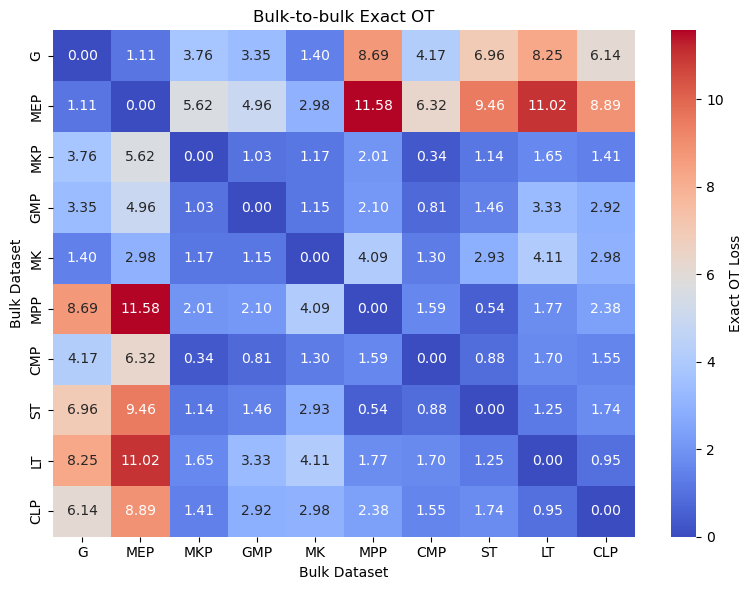

In [9]:
### Plotting heatmap ###
plt.figure(figsize=(8, 6))
sns.heatmap(exact_results, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'Exact OT Loss'})
plt.title("Bulk-to-bulk Exact OT")
plt.xlabel("Bulk Dataset")
plt.ylabel("Bulk Dataset")
plt.tight_layout()
plt.show()

## Unbalanced OT

In [10]:
### Unbalanced OT for all 4 Mb maps, no threshold, max normalization ###
uot_list = []
threshold = 0
unbalanced = 5e-1

for chr1 in chr1s_binned:
    uot_list.append(hic_ot_source_to_targets(chr1, chr1s_binned, threshold, 
                                                  'raw', 'max', unbalanced=unbalanced))

In [11]:
### Saving to pandas df ###
uot_results = pd.DataFrame(uot_list, index=map_names, columns=map_names)
uot_results

,G,MEP,MKP,GMP,MK,MPP,CMP,ST,LT,CLP
G,2.813311e-12,3.479281e+00,4.817245e+00,3.659735e+00,1.558124e+00,8.200458e+00,4.366277e+00,6.964311e+00,7.070943e+00,7.121672e+00
MEP,3.479281e+00,1.920262e-12,3.832955e+00,3.523324e+00,4.491743e+00,6.090211e+00,4.998417e+00,5.482234e+00,5.601460e+00,5.725373e+00
MKP,4.817245e+00,3.832955e+00,2.129756e-12,6.243296e-01,2.034251e+00,1.056249e+00,3.647176e-01,5.654514e-01,5.177037e-01,7.192655e-01
GMP,3.659735e+00,3.523324e+00,6.243296e-01,2.153373e-12,1.628130e+00,1.300707e+00,6.452503e-01,9.469223e-01,1.525060e+00,1.319815e+00
MK,1.558124e+00,4.491743e+00,2.034251e+00,1.628130e+00,2.763591e-12,4.265800e+00,1.353812e+00,3.303058e+00,3.266776e+00,3.585257e+00
MPP,8.200458e+00,6.090211e+00,1.056249e+00,1.300707e+00,4.265800e+00,5.144476e-12,1.411914e+00,2.417615e-01,8.448714e-01,6.407489e-01
CMP,4.366277e+00,4.998417e+00,3.647176e-01,6.452503e-01,1.353812e+00,1.411914e+00,2.378652e-12,8.260113e-01,8.489469e-01,1.002012e+00
ST,6.964311e+00,5.482234e+00,5.654514e-01,9.469223e-01,3.303058e+00,2.417615e-01,8.260113e-01,5.439150e-12,4.451485e-01,5.559739e-01
LT,7.070943e+00,5.601460e+00,5.177037e-01,1.525060e+00,3.266776e+00,8.448714e-01,8.489469e-01,4.451485e-01,5.725864e-12,6.433660e-01
CLP,7.121672e+00,5.725373e+00,7.192655e-01,1.319815e+00,3.585257e+00,6.407489e-01,1.002012e+00,5.559739e-01,6.433660e-01,5.539092e-12


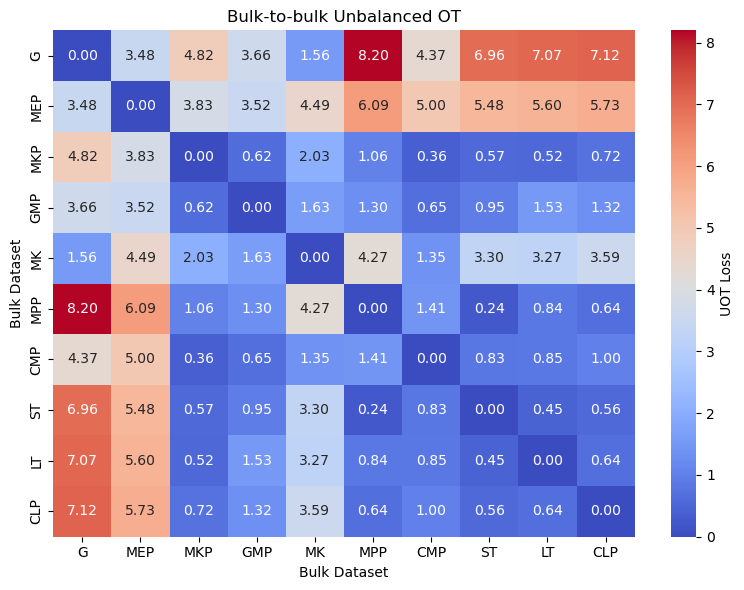

In [12]:
### Plotting heatmap ###
plt.figure(figsize=(8, 6))
sns.heatmap(uot_results, annot=True, fmt=".2f", cmap="coolwarm", cbar_kws={'label': 'UOT Loss'})
plt.title("Bulk-to-bulk Unbalanced OT")
plt.xlabel("Bulk Dataset")
plt.ylabel("Bulk Dataset")
plt.tight_layout()
plt.show()

## Comparing to SCC

In [13]:
### Importing SCC data ###
scc_file = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/mouse_scc_chr1/mouse_chr1_scc.csv'
scc_scores_1mb = pd.read_csv(scc_file, index_col=0)
scc_scores_flatten = scc_scores_1mb.values.flatten()

# Prepping results and maximum normalizing
exact_results_flatten = exact_results.values.flatten()
uot_results_flatten = uot_results.values.flatten()

### Exact

In [14]:
### Linear Regression ###
exact_regression = linregress(exact_results_flatten, scc_scores_flatten)

print(f"Slope: {exact_regression.slope:.3f}")
print(f"Intercept: {exact_regression.intercept:.3f}")
print(f"R²: {exact_regression.rvalue**2:.3f}")
print(f"P-value: {exact_regression.pvalue:.3e}")

Slope: -0.029
Intercept: 0.882
R²: 0.636
P-value: 3.031e-23


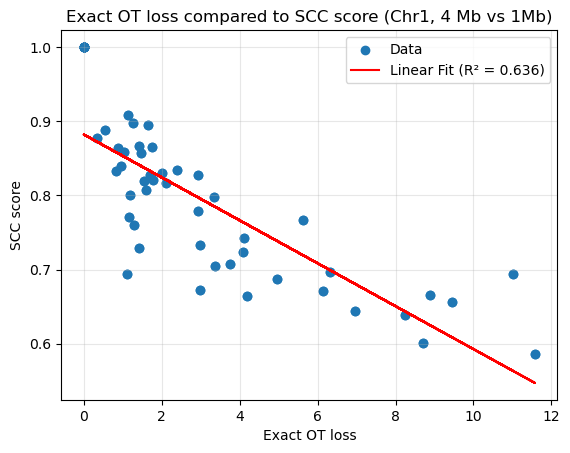

In [15]:
### Plotting Exact Relationship ###
plt.scatter(exact_results_flatten, scc_scores_flatten, label="Data")
plt.plot(exact_results_flatten, exact_regression.intercept + exact_regression.slope * 
         exact_results_flatten, color='red', label=f'Linear Fit (R\u00b2 = {exact_regression.rvalue**2:.3f})')
plt.xlabel("Exact OT loss")
plt.ylabel("SCC score")
plt.title("Exact OT loss compared to SCC score (Chr1, 4 Mb vs 1Mb)")
plt.legend()
plt.grid(alpha=0.3)

### Unbalanced

In [ ]:
### Linear Regression ###
uot_regression = linregress(uot_results_flatten, scc_scores_flatten)

print(f"Slope: {uot_regression.slope:.3f}")
print(f"Intercept: {uot_regression.intercept:.3f}")
print(f"R²: {uot_regression.rvalue**2:.3f}")
print(f"P-value: {uot_regression.pvalue:.3e}")

<class 'list'>
Slope: -0.042
Intercept: 0.896
R²: 0.799
P-value: 6.213e-36


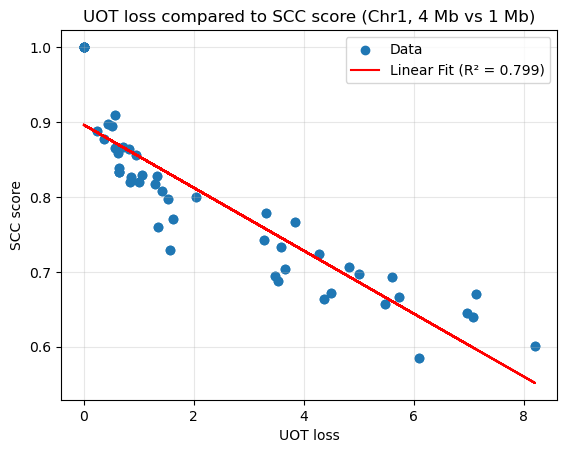

In [17]:
### Plotting Unbalanced Relationship ###
plt.scatter(uot_results_flatten, scc_scores_flatten, label='Data')
plt.plot(uot_results_flatten, uot_regression.intercept + uot_regression.slope * 
         uot_results_flatten, color='red', label=f'Linear Fit (R\u00b2 = {uot_regression.rvalue**2:.3f})')
plt.xlabel("UOT loss")
plt.ylabel("SCC score")
plt.title("UOT loss compared to SCC score (Chr1, 4 Mb vs 1 Mb)")
plt.legend()
plt.grid(alpha=0.3)